In [50]:
import numpy as np
import os
import xarray as xr
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pygmsh
import gmsh
import capytaine as cpt
from scipy.io import loadmat

import wecopttool as wot
from multibody import MbdSystem, ExternalForcesManager, evaluate_trajectories
from multibody.linearization.linearization_main import LinearizationManager
from multibody.linearization.hydro_linear_mckf import HydroLinearMCKF
from capytaine.io.legacy import export_hydrostatics
from functools import reduce

import FOSWEC_M4E_inputs

In [51]:
# Frequency object
wavefreq    = 1/8 # Hz
f1          = wavefreq
nfreq       = 10
freq        = wot.frequency(f1, nfreq, False) # False -> no zero frequency

# Define waves object
amplitude   = 0.005 # m
phase       = 0 # degrees
wavedir     = 0 # degrees
waves       = wot.waves.regular_wave(f1, nfreq, wavefreq, amplitude, phase, wavedir)

In [52]:
# platform is a rectangle with cg at -0.46 and 1.44 m long, 0.76 m wide
flapThicknessBottom = 0.04
flapThicknessTop    = 0.1
flapCenterDistanceApart = 1.44
flapWidth   = 0.76
flapHeight = 0.58
flapDraft  = 0.53
flap1CG     = [-flapCenterDistanceApart/2, 0, -0.29] # from water surface/origin
flap2CG     = [flapCenterDistanceApart/2, 0, -0.29] # from water surface/origin

platformFrameLength      = 1.44 
platformFrameThickness = 0.05
platformFrameWidth = 1.06
platformFrameTopDepth = 0.53 + 0.1
platformCG      = [0, 0, -0.8]
cutoutWidth         = platformFrameWidth - 2*platformFrameThickness
cutoutLength        = platformFrameLength - 2*platformFrameThickness

fullWidth = 1.63
columnsRadius       = 0.1
columnsDraft        = 0.53 + 0.1 + 0.4
columnsXY           = [flapCenterDistanceApart/2, fullWidth/2-columnsRadius]

daqLength = 0.72
daqWidth = 0.6
daqHeight = 0.2
daqTopDepth = 0.53 + 0.1 + 0.05

#%% Define the meshes
# Define the meshes
with pygmsh.occ.Geometry() as geom:
    gmsh.option.setNumber('Mesh.MeshSizeFactor', 0.3)
    platform = geom.add_box([-platformFrameLength/2, -platformFrameWidth/2, -platformFrameTopDepth-platformFrameThickness], [platformFrameLength,platformFrameWidth,platformFrameThickness])
    cutout = geom.add_box([-cutoutLength/2, -cutoutWidth/2, -platformFrameTopDepth-platformFrameThickness], [cutoutLength,cutoutWidth,platformFrameThickness])
    cyl1 = geom.add_cylinder([-columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl2 = geom.add_cylinder([-columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl3 = geom.add_cylinder([columnsXY[0], -columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    cyl4 = geom.add_cylinder([columnsXY[0], columnsXY[1], -columnsDraft],[0, 0, columnsDraft+.01], columnsRadius)
    DAQ = geom.add_box([-daqLength/2, -daqWidth/2, -daqTopDepth-daqHeight], [daqLength,daqWidth,daqHeight])
    platformFrame = geom.boolean_difference(platform,cutout)
    geom.boolean_union([platformFrame,DAQ,cyl1,cyl2,cyl3,cyl4])
    platformMesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap1 = geom.add_polygon(
            [[-flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [-flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [-flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap1,[0,flapWidth,0])
    flap1Mesh = geom.generate_mesh()

with pygmsh.geo.Geometry() as geom:
    flap2 = geom.add_polygon(
            [[flapCenterDistanceApart/2 - flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessBottom/2, -flapWidth/2, -flapDraft],
            [flapCenterDistanceApart/2 + flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft],
            [flapCenterDistanceApart/2 - flapThicknessTop/2, -flapWidth/2, flapHeight-flapDraft]],mesh_size=0.1)
    geom.extrude(flap2,[0,flapWidth,0])
    flap2Mesh = geom.generate_mesh()


# define the floating body
m1 = 189.8
J1 = 30
# platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform')
platform = cpt.FloatingBody(mesh=platformMesh, name=f'platform', center_of_mass=platformCG)
platform.add_all_rigid_body_dofs()
platform.rotation_center = platform.center_of_mass
# platform.inertia_matrix = platform.compute_rigid_body_inertia()
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m1,m1,m1,J1,J1,J1]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(platform.dofs),
                                    'radiating_dof': list(platform.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
platform.inertia_matrix = rigid_inertia_matrix_xr
platform.hydrostatic_stiffness = platform.immersed_part().compute_hydrostatic_stiffness()
print(platform.hydrostatic_stiffness)

# define the floating body
flap1 = cpt.FloatingBody(mesh=flap1Mesh, name=f'flap1', center_of_mass=flap1CG)
flap1.add_all_rigid_body_dofs()
#flap1.show_matplotlib()
flap1.rotation_center = flap1.center_of_mass
m2 = 23.1
J2 = 1.19
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap1.dofs),
                                    'radiating_dof': list(flap1.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap1.inertia_matrix = rigid_inertia_matrix_xr
flap1.hydrostatic_stiffness = flap1.immersed_part().compute_hydrostatic_stiffness()

# define the floating body
flap2 = cpt.FloatingBody(mesh=flap2Mesh, name=f'flap2', center_of_mass=flap2CG)
flap2.add_all_rigid_body_dofs()
flap2.rotation_center = flap2.center_of_mass
rigid_inertia_matrix_xr = xr.DataArray(data=np.asarray((np.diag([m2,m2,m2,J2,J2,J2]))),
                            dims=['influenced_dof', 'radiating_dof'],
                            coords={'influenced_dof': list(flap2.dofs),
                                    'radiating_dof': list(flap2.dofs)},
                            name="inertia_matrix")

# Set FloatingBody inertia matrix
flap2.inertia_matrix = rigid_inertia_matrix_xr
flap2.hydrostatic_stiffness = flap2.immersed_part().compute_hydrostatic_stiffness()

# Gather all bodies as a dictionary
body_inputs = {1: platform, 2: flap1, 3: flap2}
m0 = [m1, m2, m2]
J0 = [J1, J2, J2]

allbodies = platform + flap1 + flap2

<xarray.DataArray 'hydrostatic_stiffness' (influenced_dof: 6, radiating_dof: 6)> Size: 288B
array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.15534962e+03,
         1.31679650e-03,  3.27114022e-03,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.31679650e-03,
         9.32003611e+02,  6.29827066e-02,  1.07947688e-01],
       [ 0.00000000e+00,  0.00000000e+00,  3.27114022e-03,
         6.29827066e-02,  9.40275994e+02, -3.16072097e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])
Coordinates:
  * influenced_dof  (influenced_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'
  * radiating_dof   (radiating_dof) <U5 120B 'Surge' 'Sway' ... 'Pitch' 'Yaw'


In [53]:
# run BEM calculations
bem_data_file = 'foswec_WOT.nc'

if os.path.exists(bem_data_file):
    bem_data = wot.read_netcdf(bem_data_file)
else:
    bem_data = wot.run_bem(allbodies, freq, depth=2)
    bem_data['radiating_dof'] = bem_data['radiating_dof'].astype(str)
    bem_data['influenced_dof'] = bem_data['influenced_dof'].astype(str)
    wot.write_netcdf(bem_data_file, bem_data) # saves BEM data to file

body_coord = bem_data.coords["body_name"].values
com = np.vstack([b.center_of_mass for b in [platform, flap1, flap2]])
cob = np.vstack([b.center_of_buoyancy for b in [platform, flap1, flap2]])
volumes = np.array([b.immersed_part().volume for b in [platform, flap1, flap2]], dtype=float)

bem_data["center_of_mass"] = xr.DataArray(com, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["center_of_buoyancy"] = xr.DataArray(cob, dims=("bod","xyz"), coords={"body": body_coord, "xyz": ["x","y","z"]},attrs={"units": "m"})
bem_data["volume"] = xr.DataArray(volumes, dims=("bod",), coords={"body": body_coord}, attrs={"units": "m^3"})

In [54]:

# Define the multibody system
MBDsys      = MbdSystem.from_example(FOSWEC_M4E_inputs)
mainNumVars = MBDsys.ic # For now

# all_bodies = platform + flap1 + flap2
all_bodies  = reduce(lambda a, b: a + b, body_inputs.values())

#%% Linearization
# Define the equilibrium position
q0 = mainNumVars[:len(MBDsys.Q)]

# Instantiate the linearized MBD system
LinManager = LinearizationManager(MBDsys, q0, mainNumVars, m0, J0,print_sym_matrices=False)

# Instanciate and register hydrodynamics adapter
hydroAdapter = HydroLinearMCKF(
        MBDsys,
        (mainNumVars, m0, J0),
        is_2D=False,
        body_inputs=body_inputs,
        data = bem_data,
        equilibrium_pos=q0
        )

LinManager.register(hydroAdapter)

#%% Define the impedance matrix
omega = waves.omega.values
# Instantiate the total linearized system with attributes M,C,K,F
FD_system = LinManager.assemble_frequency_domain(omega)

# Extract linearized matrices
M = FD_system.M
C = FD_system.C
K = FD_system.K 
F = FD_system.Fhat

# Impedance matrix in joint coordinates
impedance_reduced = M * (1j * omega[:, None, None]) + C - 1j * K[None, :, :] * (1/omega)[:, None, None]

# Convert excitation force to xarray
excitation_reduced = xr.DataArray(F.transpose(0,2,1), coords=hydroAdapter.coords_exc, attrs={})
excitation_reduced = -excitation_reduced # negate to move to residual equation

#%% Additional forces
# transformation variables
R0 = LinManager.R0

# add forces to stabilize system
mooring_stiffness = np.diag([1e4, 1e4, 1e5, 0, 0, 0, 0, 0, 0])
mooring_stiffness = R0.T @ mooring_stiffness @ R0

mooring_damping = np.diag([1e4, 1e4, 1e4, 0, 0, 0, 0, 0, 0])
mooring_damping = R0.T @ mooring_damping @ R0

flap_linear_damping = np.diag([0, 0, 0, 500, 0, 0, 500, 0, 0])
flap_linear_damping = R0.T @ flap_linear_damping @ R0

#########################################
# Solve using wec opt tool

def f_mooring(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    mooring = -pos @ mooring_stiffness - vel @ mooring_damping
    mooring_force = jnp.dot(time_matrix,mooring)
    return mooring_force

def f_linear_damping(wec, x_wec, x_opt, wave, nsubsteps=1):
    pos = wec.vec_to_dofmat(x_wec)
    vel = jnp.dot(wec.derivative_mat,pos)
    time_matrix = wec.time_mat_nsubsteps(nsubsteps)

    damping = - vel @ flap_linear_damping
    linear_damping_force = jnp.dot(time_matrix, damping)
    return linear_damping_force

# WecOptTool does not take gravity into account and assumes equilibrium so no pretension needed
f_add = {'f_mooring': f_mooring, 'f_linear_damping': f_linear_damping} # 

#%% Define and solve the WOT object
wec = wot.WEC.from_impedance(
    waves.freq.values,
    impedance=impedance_reduced,
    exc_coeff=excitation_reduced,
    hydrostatic_stiffness=K,
    constraints=None,
    f_add=f_add,
)

# Objective function
obj_fun = lambda wec, x_wec, x_opt, waves : 0
nstate_opt = 0

# Solve
scale_x_wec = 1e1
scale_x_opt = 1e-3
scale_obj = 1e-2

results = wec.solve(
    waves,
    obj_fun,
    nstate_opt,
    scale_x_wec=scale_x_wec,
    scale_x_opt=scale_x_opt,
    scale_obj=scale_obj,
)

#%% Plot results
nsubsteps = 40
wec_fdom, wec_tdom = wec.post_process(wec, results, waves, nsubsteps=nsubsteps)

Problem initialization finished in:		 0.006 seconds
All branches in the graph:
Branch 1: [1, 2]
Branch 2: [1, 3]
R and RD matrices calculation finished in:	 0.124 seconds
Symbolic EOM computation finished in:		 0.016 seconds
Compiling EOM expressions finished in:		 0.445 seconds

[Info] Updating float body 1 IC from (x=0.0, z=0.0) → (x=0.0, z=-0.8) relative to Reference_frame_Origin: (x=0, z=0) .

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 2
            Gradient evaluations: 1


In [55]:
state_vec = np.zeros((len(wec_tdom['time']), 2*np.shape(np.squeeze(wec_tdom.pos.values))[0]))
wec_tdom_9dof = np.zeros((3*len(MBDsys.NDOF), len(wec_tdom['time'])))

for ii in range(len(wec_tdom['time'])):
    state_vec[ii,:] = np.hstack([np.squeeze(wec_tdom.pos[:,:,ii]).values, np.squeeze(wec_tdom.vel[:,:,ii]).values])
    wec_tdom_9dof[:,ii] = np.squeeze(MBDsys.Pos_func(*state_vec[ii,:]))

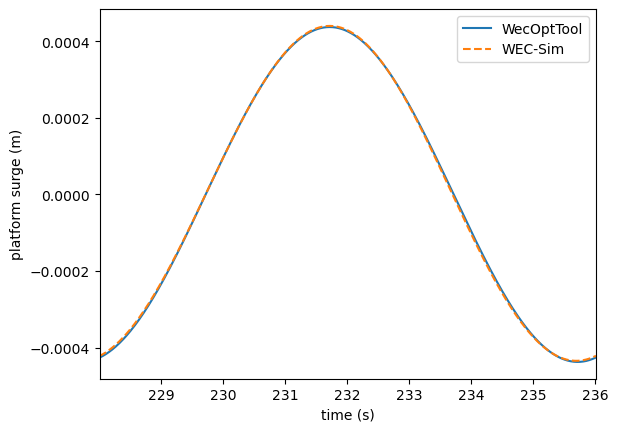

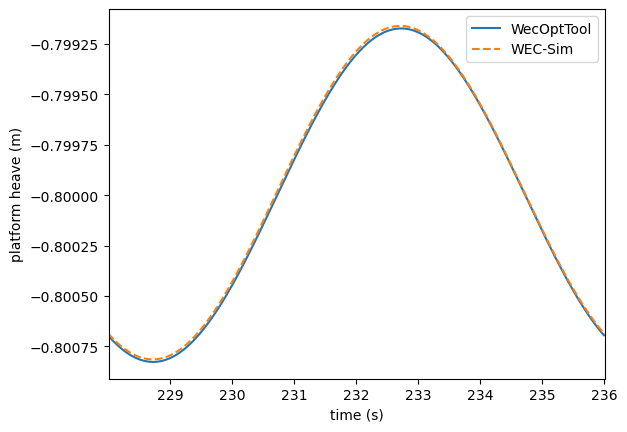

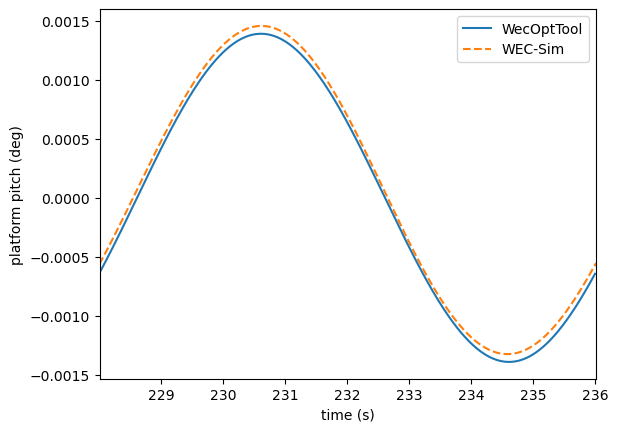

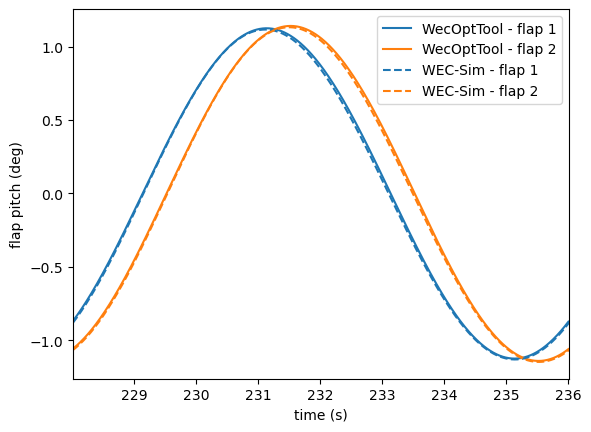

In [58]:
# load in WEC-Sim results for comparison

ws_path = 'WEC-Sim'
ws_output = loadmat(os.path.join(ws_path,'WSoutput_01.mat'), struct_as_record=False, squeeze_me=True)

phase_offset_time = 228.01

plt.figure()
plt.plot(wec_tdom['time']+phase_offset_time, wec_tdom_9dof[0,:], label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,0], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform surge (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom['time']+phase_offset_time, wec_tdom_9dof[1,:]+platformCG[2], label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,2], '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform heave (m)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom['time']+phase_offset_time, wec_tdom_9dof[2,:]*180/np.pi, label='WecOptTool')
plt.plot(ws_output['time'], ws_output['platformResponse'][:,4]*180/np.pi, '--', label='WEC-Sim')
plt.xlabel('time (s)')
plt.ylabel('platform pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()

plt.figure()
plt.plot(wec_tdom['time']+phase_offset_time, wec_tdom_9dof[5,:]*180/np.pi, color='C0', label='WecOptTool - flap 1')
plt.plot(wec_tdom['time']+phase_offset_time, wec_tdom_9dof[8,:]*180/np.pi, color='C1', label='WecOptTool - flap 2')
plt.plot(ws_output['time'], ws_output['pto1Response'][:,4]*180/np.pi, '--', color='C0', label='WEC-Sim - flap 1')
plt.plot(ws_output['time'], ws_output['pto2Response'][:,4]*180/np.pi, '--', color='C1', label='WEC-Sim - flap 2')
plt.xlabel('time (s)')
plt.ylabel('flap pitch (deg)')
plt.xlim(phase_offset_time, phase_offset_time+1/wavefreq)
plt.legend()


In [57]:
def rmse_over_timerange(t_std, y_std, t_cmp, y_cmp, t0, t1):
    """
    WEC-Sim is the standard: (t_std, y_std).
    Interpolate WecOptTool (t_cmp, y_cmp) onto t_std, then compute RMSE on [t0, t1].
    """
    t_std = np.asarray(t_std)
    y_std = np.asarray(y_std)
    t_cmp = np.asarray(t_cmp)
    y_cmp = np.asarray(y_cmp)

    mask = (t_std >= t0) & (t_std <= t1)
    tt = t_std[mask]
    y_true = y_std[mask]

    y_pred = np.interp(tt, t_cmp, y_cmp)
    max_ref                 = np.max(np.abs(y_true), axis=0) # Normalization factors from Gonzalez 2006
    rel_L2_per_DOF          = np.abs(y_pred - y_true) / max_ref
    NRMSE_per_DOF  = np.linalg.norm(rel_L2_per_DOF / len(tt), axis=0)
    #NRMSE_per_body          = np.linalg.norm(NRMSE_per_body_per_DOF,axis=-1)
    return NRMSE_per_DOF #np.sqrt(np.mean((y_pred - y_true)**2))

# time window (same as your plots)
t0 = phase_offset_time
t1 = phase_offset_time + 1/wavefreq - (wec_tdom["time"].values[1] - wec_tdom["time"].values[0]) # subtract one time step to avoid extrapolation in interpolation step below

# time vectors
t_ws  = ws_output["time"]                       # standard
t_wot = wec_tdom["time"] + phase_offset_time    # compared dataset (shifted like your plots)

# define the 5 comparisons: (name, WEC-Sim signal, WecOptTool signal)
comparisons = [
    ("platform surge (m)",
     ws_output["platformResponse"][:, 0],
     wec_tdom_9dof[0, :]),

    ("platform heave (m)",
     ws_output["platformResponse"][:, 2],
     wec_tdom_9dof[1, :] + platformCG[2]),

    ("platform pitch (deg)",
     ws_output["platformResponse"][:, 4] * 180/np.pi,
     wec_tdom_9dof[2, :] * 180/np.pi),

    ("flap 1 pitch (deg)",
     ws_output["pto1Response"][:, 4] * 180/np.pi,
     wec_tdom_9dof[5, :] * 180/np.pi),

    ("flap 2 pitch (deg)",
     ws_output["pto2Response"][:, 4] * 180/np.pi,
     wec_tdom_9dof[8, :] * 180/np.pi),
]

# compute RMSEs (pure numpy)
names = [c[0] for c in comparisons]
rmses = np.array([
    rmse_over_timerange(t_ws, y_ws, t_wot, y_wot, t0, t1)
    for (_, y_ws, y_wot) in comparisons
])

# Option A: simple "table" as a dict of numpy arrays (no pandas)
rmse_table = {"variable": np.array(names, dtype=object), "rmse": rmses}
print("RMSE over [{:.6g}, {:.6g}] s".format(t0, t1))
for n, e in zip(rmse_table["variable"], rmse_table["rmse"]):
    print(f"{n:22s}  {e:.6g}")


RMSE over [228.01, 236] s
platform surge (m)      0.000183001
platform heave (m)      4.08365e-07
platform pitch (deg)    0.0148099
flap 1 pitch (deg)      0.00042661
flap 2 pitch (deg)      0.000402875
